# Capítulo 9: Desafíos y Buenas Prácticas en IA para Ciberseguridad

**Guía Técnica:** Inteligencia Artificial en Ciberseguridad  
**Mayo 2026**

---

## 9.1. Introducción

Desplegar modelos de ML en producción implica retos continuos:

| Desafío | Impacto |
|---|---|
| **Data drift** | Las distribuciones cambian → el modelo se desactualiza |
| **Falsos positivos** | Fatiga del analista, pérdida de confianza |
| **Privacidad** | Logs sensibles, GDPR/CCPA |
| **Ataques adversariales** | Evasión de detección (Cap. 08) |
| **Explicabilidad** | Auditoría y responsabilidad (Cap. 07) |

### Contenido
| Sección | Técnica |
|---|---|
| 9.1 | Detección de data drift con Kolmogorov-Smirnov |
| 9.2 | Monitoreo de métricas en producción |
| 9.3 | Gestión de falsos positivos |
| 9.4 | Checklist de buenas prácticas |

---
## Sección 9.1: Detección de Data Drift con Kolmogorov-Smirnov

El **test KS** compara dos distribuciones sin asumir normalidad.  
Si el p-value es menor a un umbral (ej. 0.05), hay evidencia de drift significativo.

Aplicamos el test sobre el dataset de tráfico de red (Cap. 03) simulando una ventana
de producción con distribución desplazada.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

DATA_DIR = Path("../data")

df_red = pd.read_csv(DATA_DIR / "network_traffic.csv")
FEAT   = ["bytes_sent", "bytes_recv", "duration"]

# Referencia: primeras 2000 muestras ("producción inicial")
referencia = df_red[FEAT].iloc[:2000]

# Ventanas de producción simuladas
RNG = np.random.default_rng(seed=7)

ventanas = {
    "Semana 1 (normal)"       : df_red[FEAT].iloc[2000:2500],
    "Semana 2 (drift leve)"   : df_red[FEAT].iloc[2000:2500] * RNG.uniform(0.9, 1.1, df_red[FEAT].iloc[2000:2500].shape),
    "Semana 3 (drift severo)" : df_red[FEAT].iloc[2000:2500] * RNG.uniform(1.5, 3.0, df_red[FEAT].iloc[2000:2500].shape),
}

print(f"{'Ventana':<30}  {'Feature':<15}  {'KS stat':>8}  {'p-value':>10}  {'Drift?':>7}")
print("-" * 80)

resultados_drift = []
for nombre, ventana in ventanas.items():
    for feat in FEAT:
        ks_stat, p_value = stats.ks_2samp(referencia[feat].values, ventana[feat].values)
        drift = p_value < 0.05
        resultados_drift.append({
            "ventana": nombre, "feature": feat,
            "ks_stat": ks_stat, "p_value": p_value, "drift": drift
        })
        print(f"{nombre:<30}  {feat:<15}  {ks_stat:>8.4f}  {p_value:>10.4e}  {'SI' if drift else 'no':>7}")
    print()

Ventana                         Feature           KS stat     p-value   Drift?
--------------------------------------------------------------------------------
Semana 1 (normal)               bytes_sent         0.0325  7.8457e-01       no
Semana 1 (normal)               bytes_recv         0.0400  5.3630e-01       no
Semana 1 (normal)               duration           0.0405  5.2020e-01       no

Semana 2 (drift leve)           bytes_sent         0.0375  6.1906e-01       no
Semana 2 (drift leve)           bytes_recv         0.0295  8.7115e-01       no
Semana 2 (drift leve)           duration           0.0295  8.7115e-01       no

Semana 3 (drift severo)         bytes_sent         0.7260  6.2495e-208       SI
Semana 3 (drift severo)         bytes_recv         0.7200  5.7518e-204       SI
Semana 3 (drift severo)         duration           0.6390  9.1802e-156       SI



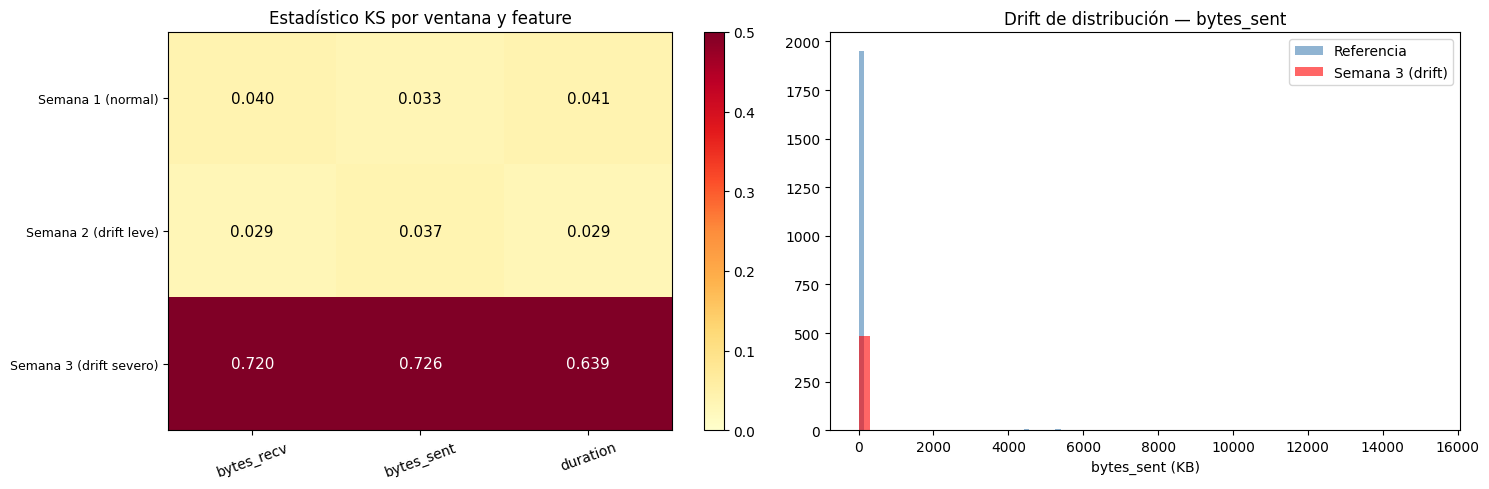

In [2]:
df_drift = pd.DataFrame(resultados_drift)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap de KS stat por ventana × feature
pivot = df_drift.pivot(index="ventana", columns="feature", values="ks_stat")
im    = axes[0].imshow(pivot.values, cmap="YlOrRd", vmin=0, vmax=0.5, aspect="auto")
axes[0].set_xticks(range(len(pivot.columns)))
axes[0].set_xticklabels(pivot.columns, rotation=20)
axes[0].set_yticks(range(len(pivot.index)))
axes[0].set_yticklabels(pivot.index, fontsize=9)
axes[0].set_title("Estadístico KS por ventana y feature")
plt.colorbar(im, ax=axes[0])
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        axes[0].text(j, i, f"{pivot.values[i,j]:.3f}",
                     ha="center", va="center", fontsize=11,
                     color="white" if pivot.values[i,j] > 0.3 else "black")

# Distribución de bytes_sent — referencia vs semana 3
axes[1].hist(referencia["bytes_sent"] / 1000, bins=50,
             alpha=0.6, color="steelblue", label="Referencia")
axes[1].hist(ventanas["Semana 3 (drift severo)"]["bytes_sent"] / 1000, bins=50,
             alpha=0.6, color="red", label="Semana 3 (drift)")
axes[1].set_xlabel("bytes_sent (KB)")
axes[1].set_title("Drift de distribución — bytes_sent")
axes[1].legend()

plt.tight_layout()
plt.savefig(DATA_DIR / "drift_resultados.png", dpi=150)
plt.show()

---
## Sección 9.2: Monitoreo de métricas en producción

Simulamos un sistema de monitoreo continuo que registra accuracy, precision, recall
y tasa de alertas semana a semana, detectando cuándo el modelo necesita reentrenamiento.

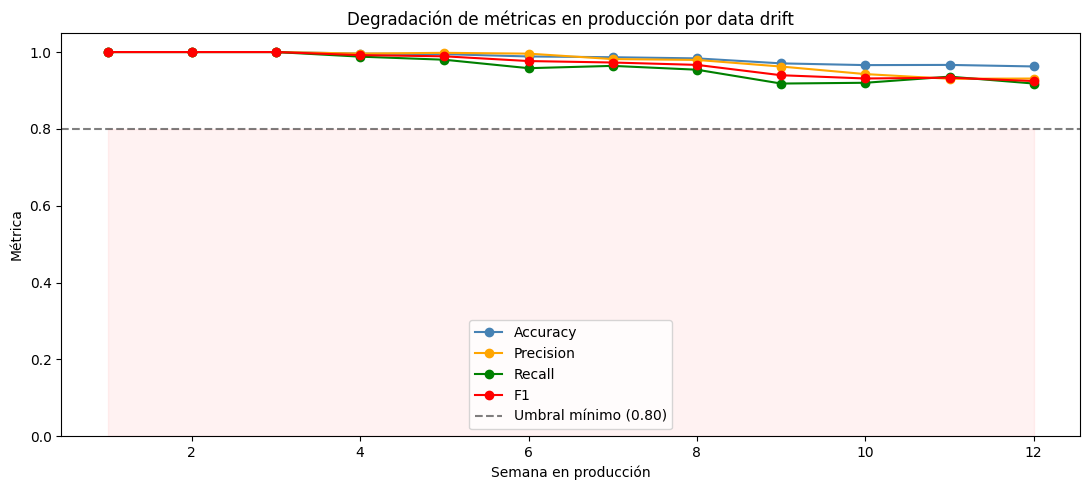

In [4]:
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

MODELS_DIR = Path("../models")
rf         = joblib.load(MODELS_DIR / "random_forest_malware.pkl")
cols       = joblib.load(MODELS_DIR / "malware_feature_cols.pkl")

df_mal = pd.read_csv(DATA_DIR / "file_features.csv")
X_base = df_mal[cols].values
y_base = df_mal["label"].values

# Simular degradación gradual semana a semana
semanas = range(1, 13)
metricas_prod = []

for semana in semanas:
    drift_factor = 1 + (semana - 1) * 0.08   # drift acumulativo
    X_prod = X_base.copy() * RNG.uniform(
        1 / drift_factor, drift_factor, X_base.shape
    )
    y_pred = rf.predict(X_prod)
    metricas_prod.append({
        "semana"   : semana,
        "accuracy" : accuracy_score(y_base, y_pred),
        "precision": precision_score(y_base, y_pred, zero_division=0),
        "recall"   : recall_score(y_base, y_pred, zero_division=0),
        "f1"       : f1_score(y_base, y_pred, zero_division=0),
    })

from sklearn.metrics import accuracy_score
df_metricas = pd.DataFrame(metricas_prod)

fig, ax = plt.subplots(figsize=(11, 5))
for col, color in [("accuracy","steelblue"),("precision","orange"),("recall","green"),("f1","red")]:
    ax.plot(df_metricas["semana"], df_metricas[col], marker="o", label=col.capitalize(), color=color)

ax.axhline(0.80, color="black", linestyle="--", alpha=0.5, label="Umbral mínimo (0.80)")
ax.fill_between(df_metricas["semana"], 0, 0.80, alpha=0.05, color="red")
ax.set_xlabel("Semana en producción")
ax.set_ylabel("Métrica")
ax.set_title("Degradación de métricas en producción por data drift")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / "monitoreo_produccion.png", dpi=150)
plt.show()

# Identificar semana de umbral
primera_caida = df_metricas[df_metricas["f1"] < 0.80]
if not primera_caida.empty:
    print(f"Alerta: F1 < 0.80 a partir de la semana {int(primera_caida.iloc[0]['semana'])} → reentrenar modelo")

---
## Sección 9.3: Gestión de falsos positivos

Analizamos el trade-off entre sensibilidad (recall) y falsos positivos ajustando
el umbral de decisión del modelo de severidad SVM.

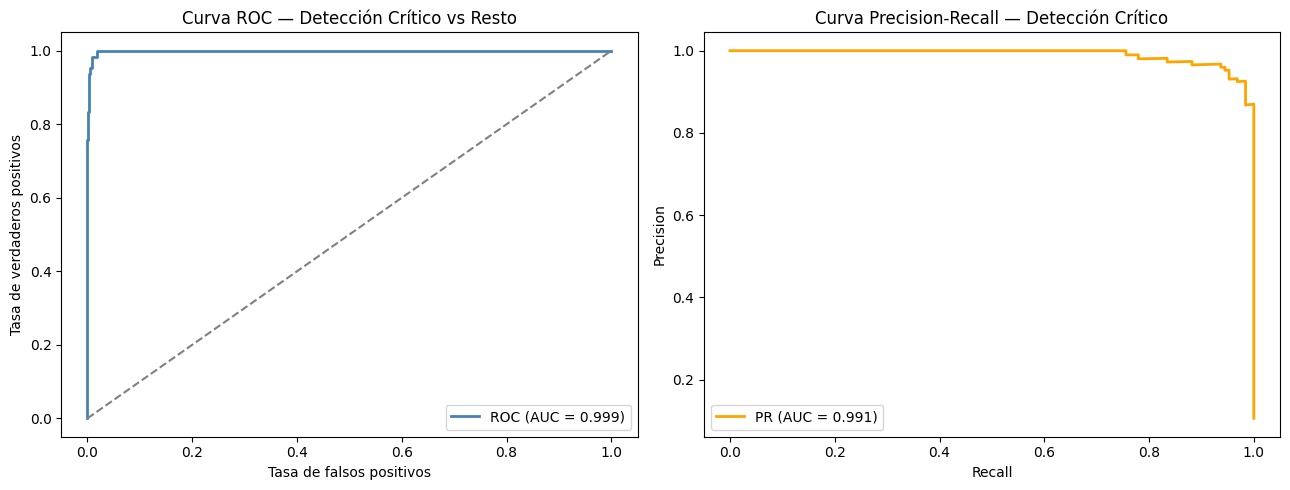

ROC-AUC: 0.9989   PR-AUC: 0.9906


In [5]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Cargamos el SVM de severidad (tratamos como binario: Crítico vs resto)
svm_sev = joblib.load(MODELS_DIR / "svm_severity.pkl")
df_inc  = pd.read_csv(DATA_DIR / "incident_data.csv")

X_inc = df_inc.drop("severity", axis=1)
y_bin = (df_inc["severity"] == 3).astype(int)   # 1=Crítico, 0=resto

proba_critico = svm_sev.predict_proba(X_inc)[:, 3]   # prob clase Crítico

fpr, tpr, thresholds = roc_curve(y_bin, proba_critico)
roc_auc = auc(fpr, tpr)

precision_c, recall_c, thresh_pr = precision_recall_curve(y_bin, proba_critico)
pr_auc = auc(recall_c, precision_c)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC (AUC = {roc_auc:.3f})")
axes[0].plot([0,1],[0,1], "--", color="gray")
axes[0].set_xlabel("Tasa de falsos positivos")
axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].set_title("Curva ROC — Detección Crítico vs Resto")
axes[0].legend()

axes[1].plot(recall_c, precision_c, color="orange", lw=2, label=f"PR (AUC = {pr_auc:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall — Detección Crítico")
axes[1].legend()

plt.tight_layout()
plt.savefig(DATA_DIR / "fp_tradeoff.png", dpi=150)
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}   PR-AUC: {pr_auc:.4f}")

---
## Sección 9.4: Checklist de buenas prácticas

| # | Práctica | Estado |
|---|---|---|
| 1 | Separación estricta train/test (stratify) | ✅ Caps 03-05 |
| 2 | Reproducibilidad con `random_state=42` y `seed=42` | ✅ Todos los capítulos |
| 3 | Persistencia de modelos con `joblib` | ✅ Caps 03-06 → 10 |
| 4 | Explicabilidad con SHAP | ✅ Cap 07 |
| 5 | Robustez ante ataques adversariales | ✅ Cap 08 |
| 6 | Monitoreo de drift en producción (KS) | ✅ Cap 09 |
| 7 | Balanceo de clases con SMOTE | ✅ Cap 04 |
| 8 | Validación cruzada (cross_val_score) | ✅ Cap 04 |
| 9 | Pipeline sklearn (previene data leakage) | ✅ Cap 05 |
| 10 | Logging estructurado en orquestación | ✅ Cap 05 |

---
**Siguiente:** Capítulo 10 → Integración Completa: Pipeline de Seguridad con IA